In [1]:
import pandas as pd
import mne
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

# Находим корень проекта (поднимаемся на уровень выше папки notebooks)
root = Path.cwd().parent
sys.path.append(str(root))

from utils import edf_tools


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
<function find_patient_edf at 0x000001FBF0B66C00>


In [ ]:
subject_list=['s01','s02','s03','s04','s05','s06','s07','s08','s09','s10','s11','s12','s13','s14']

In [ ]:
subject_list=['s05','s06','s07','s08','s09']

session_num_dict={
    's09':4,
    's07':2,
    's08':3,
    's06':4,
    's05':3,
    
}

session_num=session_num_dict[subject]


ch_to_keep={
    's09':['Fp1','Fpz','Fp2','F8','F4'],
    's07':['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','Ft7'] ,
    's08':['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','Ft7','Fc3','Fcz','Fc4','Ft8','T3'
           ,'C3','Cz','C4','T4','Tp7', 'Cp3','Cpz','Cp4','Tp8', 'Pz', 'P4','T6'],
    's06':['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','Ft7','Fc3','Fcz','Fc4','Ft8'] ,
    's05':['Fp1','Fpz','Fp2','F3','Fz','F4','F8','Fcz','Fc4','Ft8','Cpz'] ,
}

In [15]:
subject=subject_list[0]

In [17]:
files_list=[]
for i in range(1,session_num+1):
    edf_path = find_edf_first(subject, i)
    file=mne.io.read_raw_edf(edf_path)
    #file_raw=mne.io.read_raw_edf(f'../{subject}/session_1/NeoRec_2025-07-31_16-04-00_raw.edf')
    files_list.append(file)
    ch_to_drop=list(set(file.ch_names)-set(ch_to_keep[subject]))
    file.drop_channels(ch_to_drop)
    file.plot_psd()
    plt.show()

Extracting EDF parameters from c:\Users\user\Desktop\PirogovDATA\2025-06-19_s05\session_1\s05_session_1.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 1.024 (s)


C:\Users\user\AppData\Local\Temp\ipykernel_9980\2713944439.py:4: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  file=mne.io.read_raw_edf(edf_path)


Plotting power spectral density (dB=True).
Extracting EDF parameters from c:\Users\user\Desktop\PirogovDATA\2025-06-19_s05\session_2\s05_session_2.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().


C:\Users\user\AppData\Local\Temp\ipykernel_9980\2713944439.py:9: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  file.plot_psd()
C:\Users\user\AppData\Local\Temp\ipykernel_9980\2713944439.py:4: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  file=mne.io.read_raw_edf(edf_path)


Effective window size : 1.024 (s)
Plotting power spectral density (dB=True).


C:\Users\user\AppData\Local\Temp\ipykernel_9980\2713944439.py:9: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  file.plot_psd()


In [6]:
%matplotlib qt5

Using matplotlib as 2D backend.


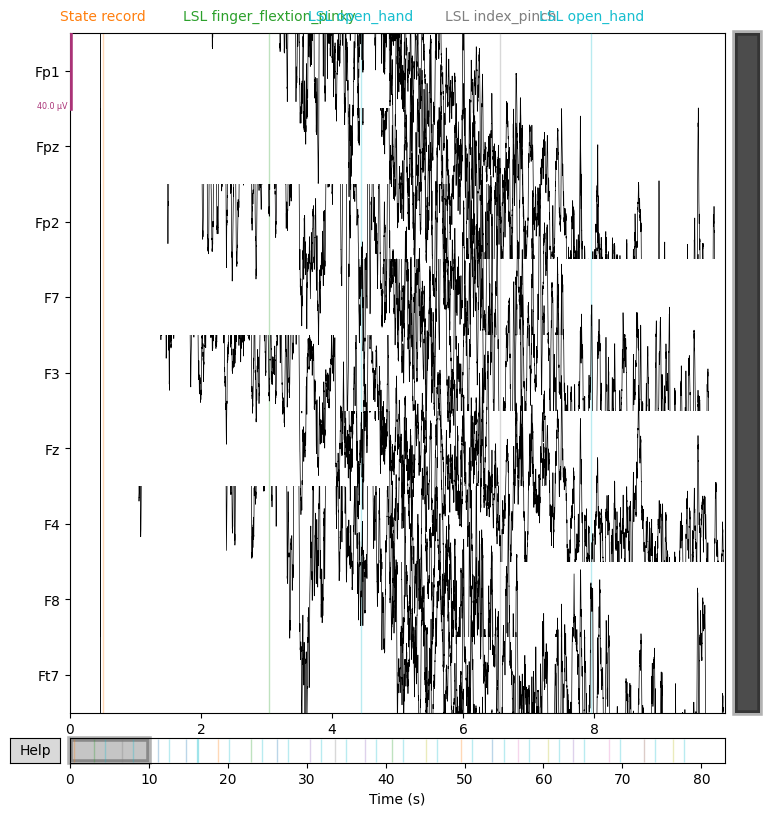

In [7]:
file.plot()

In [18]:
events=mne.events_from_annotations(file, verbose=False)[0]
events

array([[   2142,       0,      11],
       [   2876,       0,       9],
       [   7956,       0,       7],
       ...,
       [1364008,       0,       9],
       [1369750,       0,      10],
       [1372544,       0,       9]], shape=(338, 3))

In [19]:
threshold_dict={
    's09':70e-5,
    's07':3,
    's08':3,
    's06':70e-5,
    's05':70e-5,
    
}


threshold=threshold_dict[subject]

In [20]:
epochs_list=[]
for i in range(session_num):
    file=files_list[i]
    events=mne.events_from_annotations(file, verbose=False)[0]
    events_dict=mne.events_from_annotations(file, verbose=False)[1]

    epochs=mne.Epochs(file,tmin=0.0, event_id=9,tmax=1.9, baseline=(0,0.1), reject={'eeg':threshold}, preload=True)
    len(epochs)
    #for i in range(len(epochs.ch_names)):
    #epochs[10:].plot_image(i)
    epochs=mne.Epochs(file,events=events,tmin=0.0, tmax=1.9, baseline=(0,0.1), reject={'eeg':threshold}, preload=True, event_id=[1,2,3,4,5,6,7,8,10])
    epochs_list.append(epochs)
    

Used Annotations descriptions: [np.str_('LSL finger_flextion_index'), np.str_('LSL finger_flextion_middle'), np.str_('LSL finger_flextion_pinky'), np.str_('LSL finger_flextion_ring'), np.str_('LSL fist_clenching'), np.str_('LSL index_middle_pinch'), np.str_('LSL index_pinch'), np.str_('LSL middle_pinch'), np.str_('LSL open_hand'), np.str_('LSL thumb_flextion'), np.str_('State record')]
Not setting metadata
48 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Loading data for 48 events and 3801 original time points ...
0 bad epochs dropped
Not setting metadata
48 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Loading data for 48 events and 3801 original time points ...
1 bad epochs dropped
Used Annotations descriptions: [np.str_('LSL finger_flextion_index'), np.str_('LSL finger_flextion_middle'), np.str_('LSL finger_flextion_pinky'), np.str_('LSL finger_flextion_ring'), np.str_('LSL fist_clenching')

In [21]:
epochs_united=mne.concatenate_epochs(epochs_list)
events_united=epochs_united.events

out_dir = Path("1_Epochs")
out_dir.mkdir(parents=True, exist_ok=True)  # создаём, если нет

# теперь можно сохранять
epochs_united.save(out_dir / f"{subject}_epochs-epo.fif", overwrite=True)
np.savetxt(out_dir / f"{subject}_events.csv", events_united)

Not setting metadata
215 matching events found
Applying baseline correction (mode: mean)


C:\Users\user\AppData\Local\Temp\ipykernel_9980\3518087558.py:1: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  epochs_united=mne.concatenate_epochs(epochs_list)


In [22]:
for i in range(len(epochs.ch_names)):
    epochs.plot_image(i)

Not setting metadata
168 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
168 matching events found
No baseline correction applied
0 projection items activated


C:\Users\user\AppData\Local\Temp\ipykernel_9980\3186651813.py:2: RuntimeWarning: Cannot find channel coordinates in the supplied Evokeds. Not showing channel locations.
  epochs.plot_image(i)


Not setting metadata
168 matching events found
No baseline correction applied
0 projection items activated


C:\Users\user\AppData\Local\Temp\ipykernel_9980\3186651813.py:2: RuntimeWarning: Cannot find channel coordinates in the supplied Evokeds. Not showing channel locations.
  epochs.plot_image(i)


Not setting metadata
168 matching events found
No baseline correction applied
0 projection items activated


...

C:\Users\user\AppData\Local\Temp\ipykernel_9980\3186651813.py:2: RuntimeWarning: Cannot find channel coordinates in the supplied Evokeds. Not showing channel locations.
  epochs.plot_image(i)


Not setting metadata
168 matching events found
No baseline correction applied
0 projection items activated


C:\Users\user\AppData\Local\Temp\ipykernel_9980\3186651813.py:2: RuntimeWarning: Cannot find channel coordinates in the supplied Evokeds. Not showing channel locations.
  epochs.plot_image(i)
C:\Users\user\AppData\Local\Temp\ipykernel_9980\3186651813.py:2: RuntimeWarning: Cannot find channel coordinates in the supplied Evokeds. Not showing channel locations.
  epochs.plot_image(i)


Not setting metadata
168 matching events found
No baseline correction applied
0 projection items activated


C:\Users\user\AppData\Local\Temp\ipykernel_9980\3186651813.py:2: RuntimeWarning: Cannot find channel coordinates in the supplied Evokeds. Not showing channel locations.
  epochs.plot_image(i)


In [14]:
epochs_united

<EpochsArray | 133 events (all good), 0 – 1.9 s (baseline 0 – 0.1 s), ~34.7 MiB, data loaded,
 '1': 15
 '2': 15
 '3': 16
 '4': 15
 '5': 14
 '6': 14
 '7': 14
 '8': 16
 '10': 14>